# Comparación de modelos de clasificación de riesgo

## Proyecto

**VitalMind AI**


## Objetivo

Comparar visualmente los resultados iniciales de los modelos de clasificación de riesgo entrenados con datos sintéticos.

Los modelos evaluados son:

- Regresión Logística.
- Random Forest Classifier.

La comparación utilizará exclusivamente el conjunto de validación.

El conjunto de prueba permanecerá reservado hasta finalizar la selección y el ajuste del mejor modelo.

## 1. Archivos utilizados

Este notebook utilizará los siguientes artefactos:

```text
ml-service/reports/classification/initial_validation_metrics.json
ml-service/reports/classification/initial_model_comparison.csv
ml-service/reports/classification/validation_predictions.csv
```

También se cargarán los modelos serializados únicamente para revisar su estructura:

```text
ml-service/app/models/risk-classification/
```


In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Definición de rutas

Se utilizarán rutas relativas para evitar depender de la ubicación absoluta del repositorio.

In [5]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    ML_SERVICE_DIR = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "ml-service").exists():
    ML_SERVICE_DIR = NOTEBOOK_DIR / "ml-service"
else:
    ML_SERVICE_DIR = NOTEBOOK_DIR.parent

REPORTS_DIR = (
    ML_SERVICE_DIR
    /".."
    / "reports"
    / "classification"
)

MODELS_DIR = (
    ML_SERVICE_DIR
    /".."
    / "app"
    / "models"
    / "risk-classification"
)

METRICS_PATH = (
    REPORTS_DIR
    
    / "initial_validation_metrics.json"
)

COMPARISON_PATH = (
    REPORTS_DIR

    / "initial_model_comparison.csv"
)

PREDICTIONS_PATH = (
    REPORTS_DIR
    / "validation_predictions.csv"
)

LOGISTIC_MODEL_PATH = (
    MODELS_DIR
    / "logistic_regression_pipeline.joblib"
)

RANDOM_FOREST_MODEL_PATH = (
    MODELS_DIR
    / "random_forest_pipeline.joblib"
)

LABEL_ENCODER_PATH = (
    MODELS_DIR
    / "risk_label_encoder.joblib"
)

paths = {
    "Métricas": METRICS_PATH,
    "Comparación": COMPARISON_PATH,
    "Predicciones": PREDICTIONS_PATH,
    "Regresión Logística": LOGISTIC_MODEL_PATH,
    "Random Forest": RANDOM_FOREST_MODEL_PATH,
    "Label Encoder": LABEL_ENCODER_PATH,
}

for name, path in paths.items():
    print(f"{name}: {path.exists()} — {path}")

Métricas: True — C:\Users\otero\OneDrive\Desktop\9A-IDGS-ECBD-VitalMind-\ml-service\app\..\reports\classification\initial_validation_metrics.json
Comparación: True — C:\Users\otero\OneDrive\Desktop\9A-IDGS-ECBD-VitalMind-\ml-service\app\..\reports\classification\initial_model_comparison.csv
Predicciones: True — C:\Users\otero\OneDrive\Desktop\9A-IDGS-ECBD-VitalMind-\ml-service\app\..\reports\classification\validation_predictions.csv
Regresión Logística: True — C:\Users\otero\OneDrive\Desktop\9A-IDGS-ECBD-VitalMind-\ml-service\app\..\app\models\risk-classification\logistic_regression_pipeline.joblib
Random Forest: True — C:\Users\otero\OneDrive\Desktop\9A-IDGS-ECBD-VitalMind-\ml-service\app\..\app\models\risk-classification\random_forest_pipeline.joblib
Label Encoder: True — C:\Users\otero\OneDrive\Desktop\9A-IDGS-ECBD-VitalMind-\ml-service\app\..\app\models\risk-classification\risk_label_encoder.joblib


## 3. Carga de métricas, comparación y predicciones

In [6]:
with METRICS_PATH.open(
    "r",
    encoding="utf-8",
) as metrics_file:
    metrics_data = json.load(metrics_file)

comparison_df = pd.read_csv(COMPARISON_PATH)
predictions_df = pd.read_csv(PREDICTIONS_PATH)

label_encoder = joblib.load(LABEL_ENCODER_PATH)

print("Archivos cargados correctamente.")
print(f"Modelos evaluados: {len(metrics_data)}")
print(f"Filas en comparación: {len(comparison_df)}")
print(f"Predicciones registradas: {len(predictions_df):,}")
print(f"Clases: {label_encoder.classes_.tolist()}")

Archivos cargados correctamente.
Modelos evaluados: 2
Filas en comparación: 2
Predicciones registradas: 1,462
Clases: ['high', 'low', 'medium']


In [7]:
comparison_df

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,roc_auc_weighted_ovr
0,logistic_regression,0.8933,0.8935,0.8933,0.8929,0.8933,0.9771
1,random_forest,0.8824,0.8826,0.8824,0.8821,0.8825,0.9701


## 4. Resumen inicial de resultados

La tabla contiene las métricas globales calculadas sobre el conjunto de validación:

- Accuracy.
- Presicion ponderada.
- Recall ponderada.
- F1 ponderado.
- F1 macro.
- ROC-AUC multiclase.

In [8]:
with METRICS_PATH.open(
    "r",
    encoding="utf-8",
) as metrics_file:
    metrics_data = json.load(metrics_file)

comparison_df = pd.read_csv(COMPARISON_PATH)
predictions_df = pd.read_csv(PREDICTIONS_PATH)

label_encoder = joblib.load(LABEL_ENCODER_PATH)

print("Archivos cargados correctamente.")
print(f"Modelos evaluados: {len(metrics_data)}")
print(f"Filas en comparación: {len(comparison_df)}")
print(f"Predicciones registradas: {len(predictions_df):,}")
print(f"Clases: {label_encoder.classes_.tolist()}")

Archivos cargados correctamente.
Modelos evaluados: 2
Filas en comparación: 2
Predicciones registradas: 1,462
Clases: ['high', 'low', 'medium']


In [9]:
comparison_display = (
    comparison_df[
        [
            "model",
            "accuracy",
            "precision_weighted",
            "recall_weighted",
            "f1_weighted",
            "f1_macro",
            "roc_auc_weighted_ovr",
        ]
    ]
    .copy()
    .sort_values(
        by="f1_macro",
        ascending=False,
    )
)

comparison_display

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,roc_auc_weighted_ovr
0,logistic_regression,0.8933,0.8935,0.8933,0.8929,0.8933,0.9771
1,random_forest,0.8824,0.8826,0.8824,0.8821,0.8825,0.9701


In [10]:
best_model_row = comparison_display.iloc[0]

print("Mejor modelo provisional:")
print(best_model_row["model"])

print("\nMétricas principales:")
print(f"Accuracy: {best_model_row['accuracy']:.4f}")
print(f"F1 macro: {best_model_row['f1_macro']:.4f}")
print(
    "ROC-AUC ponderado: "
    f"{best_model_row['roc_auc_weighted_ovr']:.4f}"
)

Mejor modelo provisional:
logistic_regression

Métricas principales:
Accuracy: 0.8933
F1 macro: 0.8933
ROC-AUC ponderado: 0.9771


## 5. Comparación visual de métricas globales

Se compararán los modelos utilizando las principales métricas de clasificación.

F1 macro tendrá especial importancia porque asigna el mismo peso a cada clase, independientemente de su frecuencia.

<Figure size 1100x600 with 0 Axes>

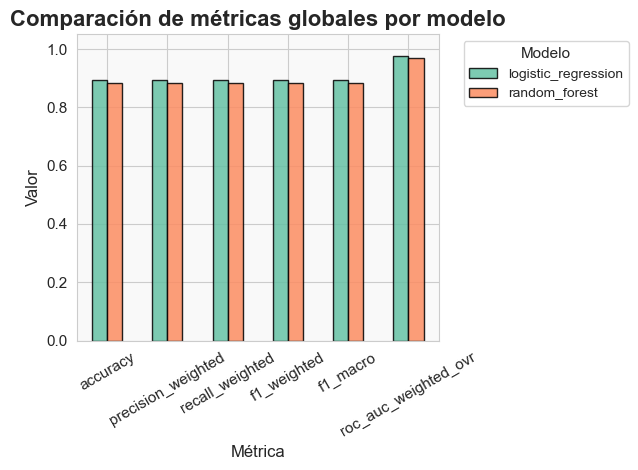

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

plt.figure(figsize=(11,6))

ax = metrics_for_plot.plot(
    kind="bar",
    color=sns.color_palette("Set2", len(metrics_for_plot.columns)),
    edgecolor="black",
    alpha=0.85
)

# Títulos y etiquetas llamativas
ax.set_title("Comparación de métricas globales por modelo", fontsize=16, fontweight="bold")
ax.set_xlabel("Métrica", fontsize=12)
ax.set_ylabel("Valor", fontsize=12)

# Ajuste de ticks
ax.tick_params(axis="x", rotation=30, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# Límites claros
ax.set_ylim(0, 1.05)

# Leyenda estilizada
ax.legend(title="Modelo", fontsize=10, title_fontsize=11, bbox_to_anchor=(1.05, 1), loc="upper left")

# Fondo claro
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()


<Figure size 800x400 with 0 Axes>

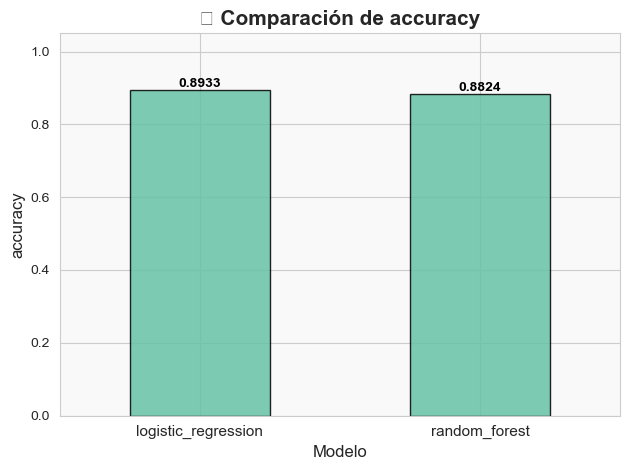

<Figure size 800x400 with 0 Axes>

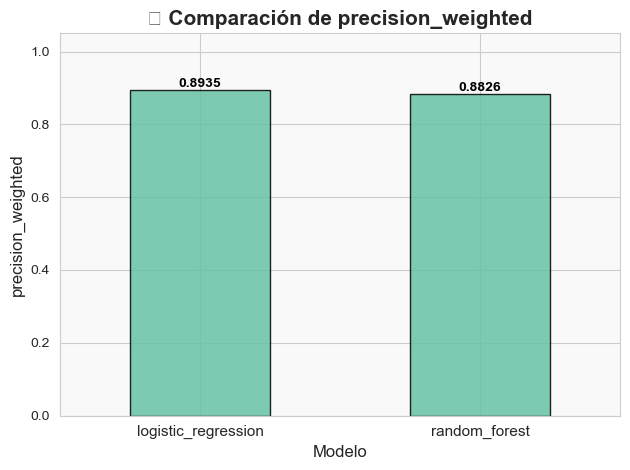

<Figure size 800x400 with 0 Axes>

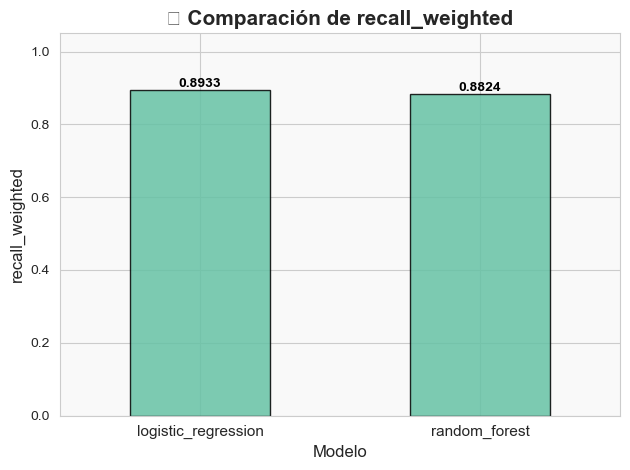

<Figure size 800x400 with 0 Axes>

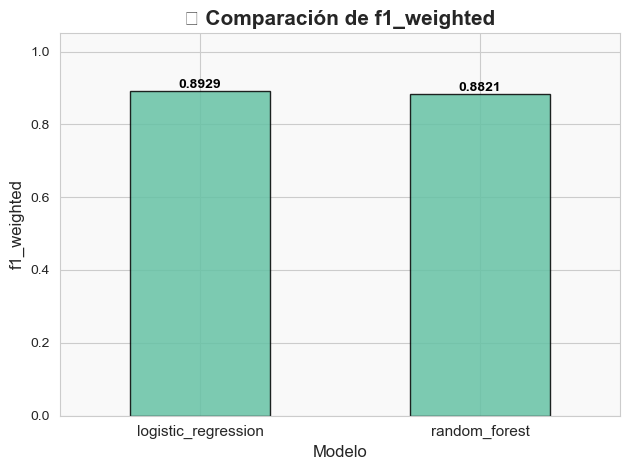

<Figure size 800x400 with 0 Axes>

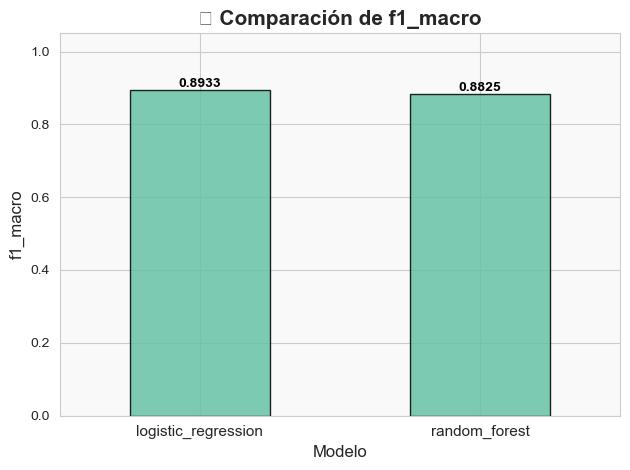

<Figure size 800x400 with 0 Axes>

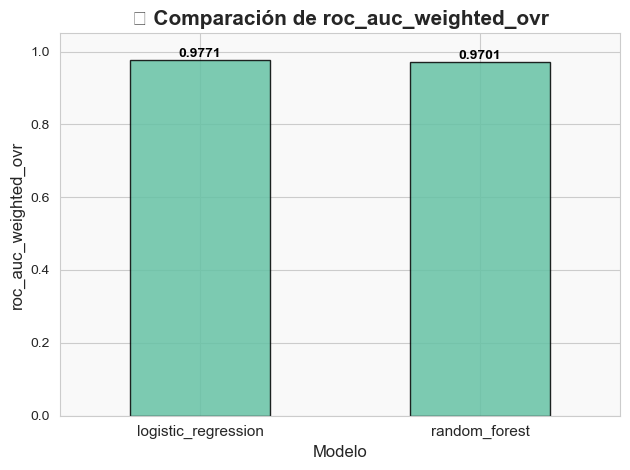

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

for metric in global_metrics:
    metric_values = (
        comparison_display[["model", metric]]
        .set_index("model")
    )
    
    plt.figure(figsize=(8,4))
    
    # Barras estilizadas
    ax = metric_values.plot(
        kind="bar",
        color=sns.color_palette("Set2", len(metric_values)),
        edgecolor="black",
        alpha=0.85,
        legend=False
    )
    
    # Títulos y etiquetas llamativas
    ax.set_title(f"✨ Comparación de {metric}", fontsize=15, fontweight="bold")
    ax.set_xlabel("Modelo", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=0, labelsize=11)
    
    # Etiquetas encima de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", fontsize=10, fontweight="bold", color="black")
    
    # Fondo claro
    plt.gca().set_facecolor("#f9f9f9")
    
    plt.tight_layout()
    plt.show()


### Interpretación inicial

La Regresión Logística presenta el mejor resultado provisional en:

- Accuracy.
- Precision ponderada.
- Recall ponderado.
- F1 ponderado.
- F1 macro.
- ROC-AUC multiclase.

La diferencia con Random Forest es moderada, por lo que ambos modelos deberán mantenerse para el análisis detallado.

La selección definitiva todavía no debe realizarse porque falta:

- Revisar el desempeño por clase.
- Analizar las matrices de confusión.
- Revisar las probabilidades.
- Ajustar hiperparámetros.
- Evaluar una sola vez sobre el conjunto de prueba.

## 6. Preparación de métricas por modelo

El archivo JSON contiene: 

- Métricas globales.
- Reporte de clasificación.
- Matriz de confusión.
- Orden de las clases.

In [15]:
metrics_by_model = {
    item["model"]:item
    for item in metrics_data
}
print(metrics_by_model.keys())

dict_keys(['logistic_regression', 'random_forest'])


In [16]:
for model_name, model_metrics in metrics_by_model.items():
    print("\n"+"="*60)
    print(model_name)
    print("="*60)

    report_df = pd.DataFrame(
        model_metrics["classification_report"]
    ).T

    display(
        report_df.round(4)
    )


logistic_regression


,precision,recall,f1-score,support
high,0.8549,0.9066,0.8800,182.0000
low,0.9266,0.9449,0.9357,254.0000
medium,0.8889,0.8407,0.8641,295.0000
accuracy,0.8933,0.8933,0.8933,0.8933
macro avg,0.8902,0.8974,0.8933,731.0000
weighted avg,0.8935,0.8933,0.8929,731.0000



random_forest


,precision,recall,f1-score,support
high,0.8446,0.8956,0.8693,182.0000
low,0.9222,0.9331,0.9276,254.0000
medium,0.8719,0.8305,0.8507,295.0000
accuracy,0.8824,0.8824,0.8824,0.8824
macro avg,0.8795,0.8864,0.8825,731.0000
weighted avg,0.8826,0.8824,0.8821,731.0000


## 7. Matrices de confusión

La matriz de confusión permite identificar:

- Predicciones correctas por clase.
- Clases que el modelo confunde con mayor frecuencia.
- Errrores entre niveles cercanos de riesgo.
- Posibles diferencias entre Regresión Logística y Random Forest.

In [17]:
class_order = label_encoder.classes_.tolist()

print("Orden de clases:")
print(class_order)

Orden de clases:
['high', 'low', 'medium']


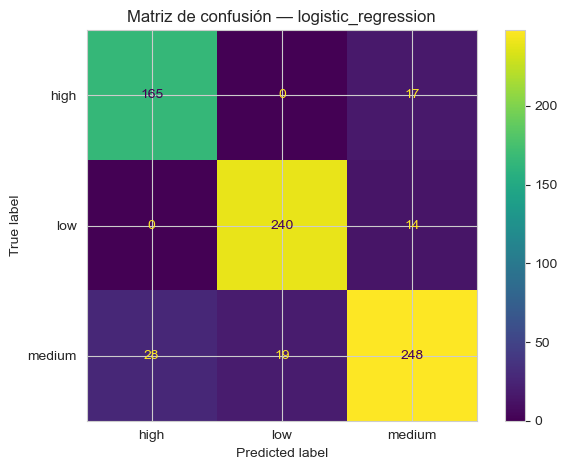

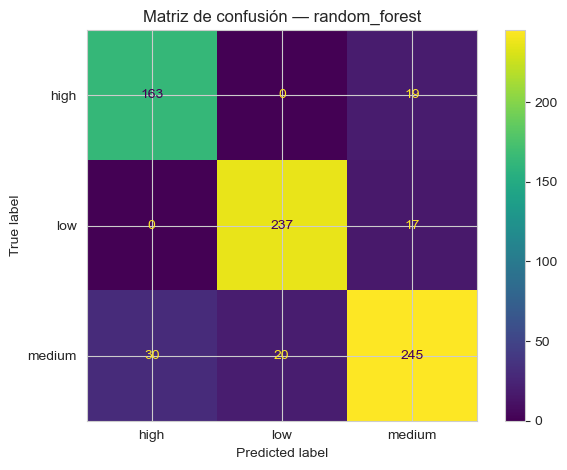

In [18]:
for model_name, model_metrics in metrics_by_model.items():
    matrix = np.array(
        model_metrics["confusion_matrix"]
    )

    display_object = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=class_order,
    )

    display_object.plot(
        values_format="d",
    )

    plt.title(
        f"Matriz de confusión — {model_name}"
    )
    plt.tight_layout()
    plt.show()

### Interpretación de las matrices

En ambos modelos se espera observar que:

- La clase `low` presenta una alta cantidad de predicciones correctas.
- La clase `high` se confunde principalmente con `medium`.
- La clase `medium` concentra la mayor cantidad de errores.
- No existen confusiones directas relevantes entre `high` y `low`.

Este comportamiento es razonable porque `medium` representa casos cercanos a los límites entre riesgo bajo y alto.

In [19]:
confusion_summary_rows = []

for model_name, model_metrics in metrics_by_model.items():
    matrix = np.array(
        model_metrics["confusion_matrix"]
    )

    for class_index, class_name in enumerate(class_order):
        true_positive = matrix[
            class_index,
            class_index,
        ]

        total_actual = matrix[
            class_index,
            :,
        ].sum()

        correct_percentage = (
            true_positive / total_actual * 100
            if total_actual > 0
            else 0
        )

        confusion_summary_rows.append(
            {
                "model": model_name,
                "class": class_name,
                "correct_predictions": int(
                    true_positive
                ),
                "actual_records": int(
                    total_actual
                ),
                "correct_percentage": (
                    correct_percentage
                ),
            }
        )

confusion_summary_df = pd.DataFrame(
    confusion_summary_rows
)

confusion_summary_df.round(2)

,model,class,correct_predictions,actual_records,correct_percentage
0,logistic_regression,high,165,182,90.6600
1,logistic_regression,low,240,254,94.4900
2,logistic_regression,medium,248,295,84.0700
3,random_forest,high,163,182,89.5600
4,random_forest,low,237,254,93.3100
5,random_forest,medium,245,295,83.0500


## 8. Comparación del desempeño por clase

Las métricas globales pueden ocultar diferencias importantes.

Se analizarán individualmente:

- Precisión
- Recall
- F1-Score
- Cantidad de registroos por clase.
  

In [20]:
class_metric_rows = []

for model_name, model_metrics in metrics_by_model.items():
    classification_report_data = (
        model_metrics["classification_report"]
    )

    for class_name in class_order:
        class_metrics = (
            classification_report_data[
                class_name
            ]
        )

        class_metric_rows.append(
            {
                "model": model_name,
                "class": class_name,
                "precision": class_metrics[
                    "precision"
                ],
                "recall": class_metrics[
                    "recall"
                ],
                "f1_score": class_metrics[
                    "f1-score"
                ],
                "support": class_metrics[
                    "support"
                ],
            }
        )

class_metrics_df = pd.DataFrame(
    class_metric_rows
)

class_metrics_df.round(4)

,model,class,precision,recall,f1_score,support
0,logistic_regression,high,0.8549,0.9066,0.8800,182.0000
1,logistic_regression,low,0.9266,0.9449,0.9357,254.0000
2,logistic_regression,medium,0.8889,0.8407,0.8641,295.0000
3,random_forest,high,0.8446,0.8956,0.8693,182.0000
4,random_forest,low,0.9222,0.9331,0.9276,254.0000
5,random_forest,medium,0.8719,0.8305,0.8507,295.0000


<Figure size 900x500 with 0 Axes>

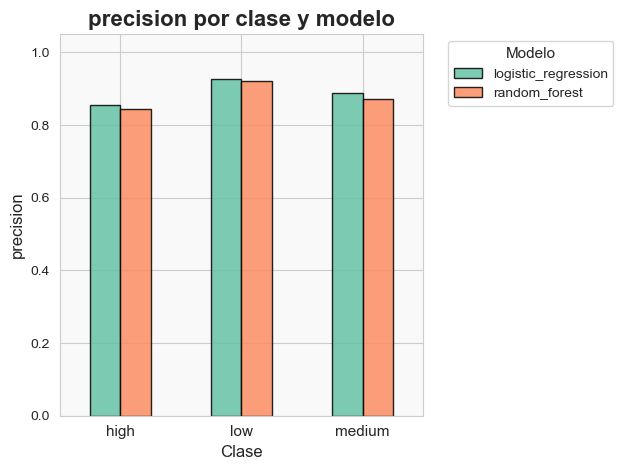

<Figure size 900x500 with 0 Axes>

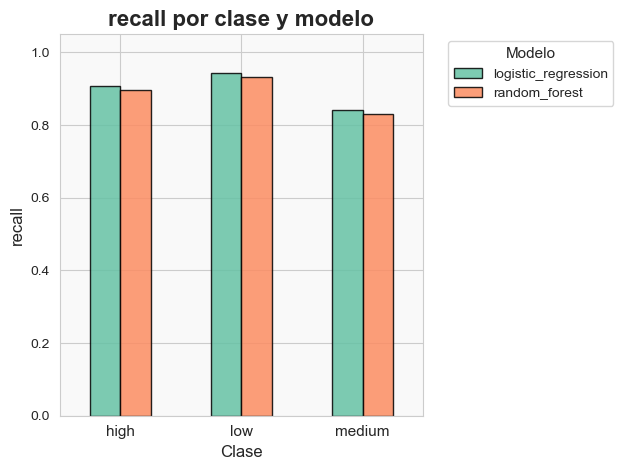

<Figure size 900x500 with 0 Axes>

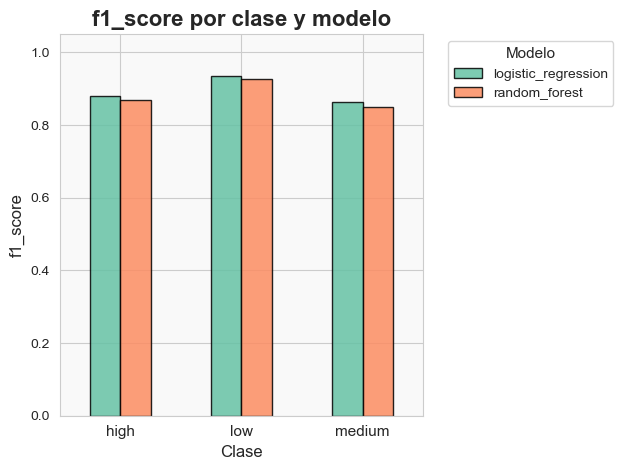

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

for metric in ["precision", "recall", "f1_score"]:
    metric_table = (
        class_metrics_df
        .pivot(index="class", columns="model", values=metric)
        .reindex(class_order)
    )
    
    plt.figure(figsize=(9,5))
    
    # Barras agrupadas con colores diferenciados
    ax = metric_table.plot(
        kind="bar",
        color=sns.color_palette("Set2", len(metric_table.columns)),
        edgecolor="black",
        alpha=0.85
    )
    
    # Títulos y etiquetas llamativas
    ax.set_title(f"{metric} por clase y modelo", fontsize=16, fontweight="bold")
    ax.set_xlabel("Clase", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=0, labelsize=11)
    
    # Leyenda estilizada
    ax.legend(title="Modelo", fontsize=10, title_fontsize=11, bbox_to_anchor=(1.05, 1), loc="upper left")
    
    # Fondo claro
    plt.gca().set_facecolor("#f9f9f9")
    
    plt.tight_layout()
    plt.show()


In [24]:
f1_class_comparison = (
    class_metrics_df
    .pivot(
        index="class",
        columns="model",
        values="f1_score",
    )
    .reindex(class_order)
)

f1_class_comparison.round(4)

model,logistic_regression,random_forest
class,,
high,0.8800,0.8693
low,0.9357,0.9276
medium,0.8641,0.8507


### Interpretación por clase

La Regresión Logística presenta un desempeño ligeramente superior en las tres clases.

La clase `medium` representa el principal reto para ambos modelos porque contiene registros con características intermedias.

Para el proyecto es especialmente importante revisar el `Recall` de la clase `high`, debido a que una baja recuperación implicaría dejar sin identificar registros de riesgo preventivo elevado.

## 9. Análisis de predicciones incorrectas

Se identificarán:

- Cantidad de errores por modelo.
- Pares de clases más confundidos.
- Probabilidad asignada a la predicción.
- Casos correctos con baja confianza.
- Casos incorrectos con alta confianza

In [25]:
predictions_df["is_correct"] = (
    predictions_df["actual_risk_level"]
    == predictions_df["predicted_risk_level"]
)

error_summary = (
    predictions_df
    .groupby("model")
    .agg(
        total_predictions=(
            "is_correct",
            "size",
        ),
        correct_predictions=(
            "is_correct",
            "sum",
        ),
        incorrect_predictions=(
            "is_correct",
            lambda values: (
                ~values
            ).sum(),
        ),
        accuracy_calculated=(
            "is_correct",
            "mean",
        ),
    )
)

error_summary.round(4)

,total_predictions,correct_predictions,incorrect_predictions,accuracy_calculated
model,,,,
logistic_regression,731,653,78,0.8933
random_forest,731,645,86,0.8824


In [27]:
incorrect_predictions = (
    predictions_df[
        ~predictions_df["is_correct"]
    ]
    .copy()
)

error_pairs = (
    incorrect_predictions
    .groupby(
        [
            "model",
            "actual_risk_level",
            "predicted_risk_level",
        ]
    )
    .size()
    .reset_index(name="errors")
    .sort_values(
        by=["model", "errors"],
        ascending=[True, False],
    )
)

error_pairs

,model,actual_risk_level,predicted_risk_level,errors
2,logistic_regression,medium,high,28
3,logistic_regression,medium,low,19
0,logistic_regression,high,medium,17
1,logistic_regression,low,medium,14
6,random_forest,medium,high,30
7,random_forest,medium,low,20
4,random_forest,high,medium,19
5,random_forest,low,medium,17


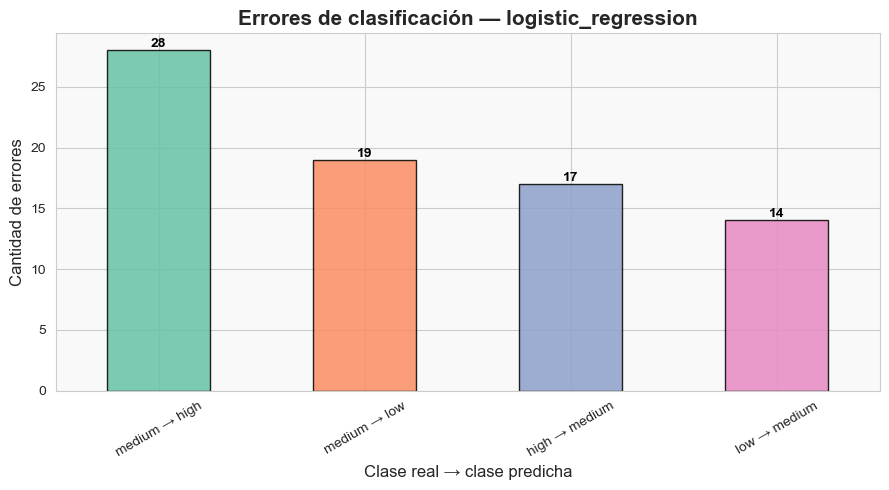

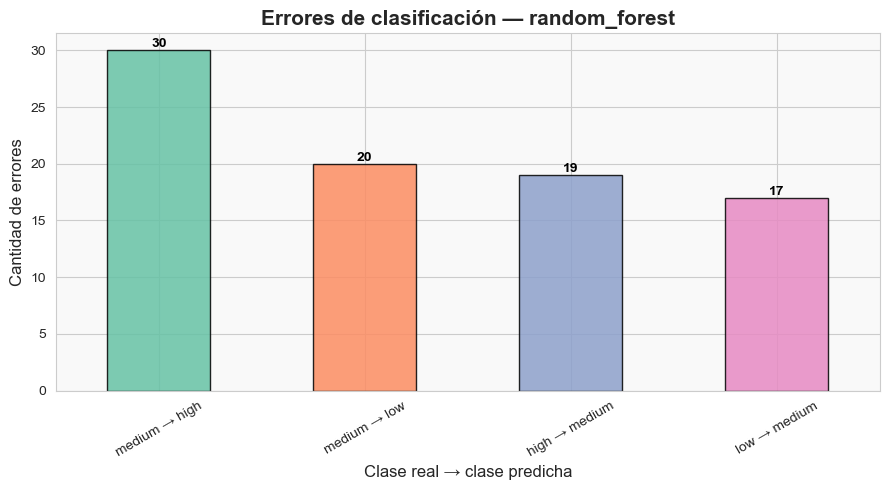

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

for model_name in predictions_df["model"].unique():
    model_errors = error_pairs[error_pairs["model"] == model_name].copy()
    
    labels = model_errors["actual_risk_level"] + " → " + model_errors["predicted_risk_level"]
    
    plt.figure(figsize=(9,5))
    
    ax = model_errors.set_index(labels)["errors"].plot(
        kind="bar",
        color=sns.color_palette("Set2", len(model_errors)),
        edgecolor="black",
        alpha=0.85
    )
    
    # Títulos y etiquetas llamativas
    ax.set_title(f"Errores de clasificación — {model_name}", fontsize=15, fontweight="bold")
    ax.set_xlabel("Clase real → clase predicha", fontsize=12)
    ax.set_ylabel("Cantidad de errores", fontsize=12)
    ax.tick_params(axis="x", rotation=30, labelsize=10)
    
    # Etiquetas encima de cada barra
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fontweight="bold", color="black")
    
    # Fondo claro
    plt.gca().set_facecolor("#f9f9f9")
    
    plt.tight_layout()
    plt.show()


In [31]:
probability_columns = [
    column
    for column in predictions_df.columns
    if column.startswith("probability_")
]

probability_columns

['probability_high', 'probability_low', 'probability_medium']

In [32]:
predictions_df[
    "prediction_confidence"
] = predictions_df[
    probability_columns
].max(axis=1)

confidence_summary = (
    predictions_df
    .groupby(
        [
            "model",
            "is_correct",
        ]
    )["prediction_confidence"]
    .agg(
        records="count",
        mean_confidence="mean",
        median_confidence="median",
        minimum_confidence="min",
        maximum_confidence="max",
    )
    .round(4)
)

confidence_summary

records  mean_confidence  median_confidence  \
model               is_correct                                                
logistic_regression False            78           0.7075             0.6689   
                    True            653           0.9057             0.9585   
random_forest       False            86           0.6439             0.6341   
                    True            645           0.8248             0.8572   

                                minimum_confidence  maximum_confidence  
model               is_correct                                          
logistic_regression False                   0.5063              0.9798  
                    True                    0.5063              1.0000  
random_forest       False                   0.4918              0.9533  
                    True                    0.4951              1.0000

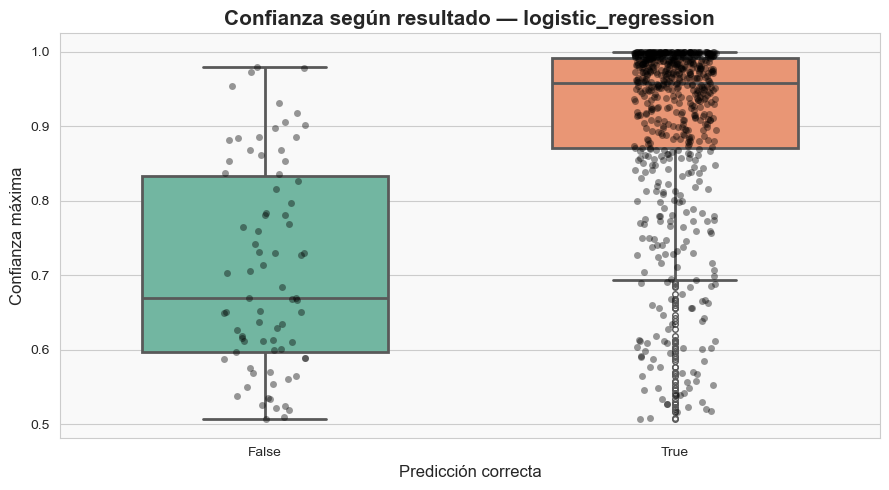

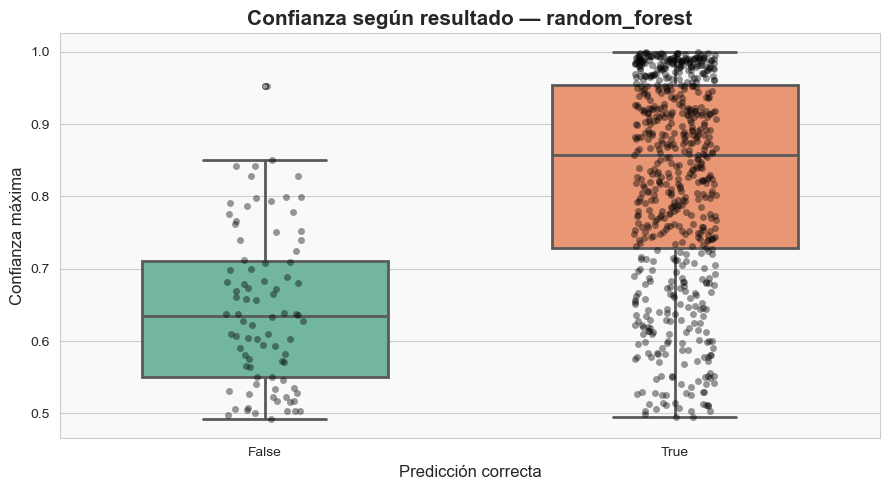

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

for model_name in predictions_df["model"].unique():
    model_predictions = predictions_df[predictions_df["model"] == model_name]
    
    plt.figure(figsize=(9,5))
    
    # Boxplot estilizado
    sns.boxplot(
        data=model_predictions,
        x="is_correct",
        y="prediction_confidence",
        palette="Set2",
        width=0.6,
        linewidth=2,
        fliersize=4
    )
    
    # Overlay con puntos individuales (para ver dispersión real)
    sns.stripplot(
        data=model_predictions,
        x="is_correct",
        y="prediction_confidence",
        color="black",
        alpha=0.4,
        jitter=True
    )
    
    # Títulos y etiquetas llamativas
    plt.title(f"Confianza según resultado — {model_name}", fontsize=15, fontweight="bold")
    plt.xlabel("Predicción correcta", fontsize=12)
    plt.ylabel("Confianza máxima", fontsize=12)
    
    # Fondo claro
    plt.gca().set_facecolor("#f9f9f9")
    
    plt.tight_layout()
    plt.show()


In [36]:
high_confidence_errors = (
    predictions_df[
        (~predictions_df["is_correct"])
        & (
            predictions_df[
                "prediction_confidence"
            ]
            >= 0.80
        )
    ]
    .sort_values(
        "prediction_confidence",
        ascending=False,
    )
)

print(
    "Errores con confianza igual "
    "o superior a 0.80:"
)
print(len(high_confidence_errors))

high_confidence_errors.head(15)

Errores con confianza igual o superior a 0.80:
28


,actual_encoded,predicted_encoded,actual_risk_level,predicted_risk_level,model,probability_high,probability_low,probability_medium,is_correct,prediction_confidence
522,2,0,medium,high,logistic_regression,0.9798,0.0000,0.0202,False,0.9798
286,2,1,medium,low,logistic_regression,0.0000,0.9787,0.0213,False,0.9787
456,2,1,medium,low,logistic_regression,0.0000,0.9728,0.0272,False,0.9728
656,2,1,medium,low,logistic_regression,0.0000,0.9543,0.0457,False,0.9543
783,2,1,medium,low,random_forest,0.0013,0.9533,0.0455,False,0.9533
658,2,0,medium,high,logistic_regression,0.9309,0.0000,0.0691,False,0.9309
226,1,2,low,medium,logistic_regression,0.0024,0.0796,0.9180,False,0.9180
121,0,2,high,medium,logistic_regression,0.0931,0.0016,0.9053,False,0.9053
322,2,0,medium,high,logistic_regression,0.9010,0.0000,0.0990,False,0.9010
625,0,2,high,medium,logistic_regression,0.0014,0.1005,0.8980,False,0.8980


### Interpretación de la confianza

Un modelo puede equivocarse incluso cuando asigna una probabilidad elevada.

Los errores con alta confianza deben analizarse porque podrían indicar:

- Casos frontera mal representados.
- Variables insuficientes.
- Relaciones artificiales en la simulación.
- Necesidad de calibrar probabilidades.
- Casos con combinaciones poco comunes.

La probabilidad del modelo no deberá presentarse como certeza.

## 10. Coparación de predicciones entre modelos

Se revisará en cuántos casos ambos modelos:

- Aciertan.
- Se equivocan.
- Porducen predicciones diferentes.
- Identifican correctamaente la clase `high`

In [37]:
logistic_predictions = (
    predictions_df[
        predictions_df["model"]
        == "logistic_regression"
    ]
    .reset_index(drop=True)
)

forest_predictions = (
    predictions_df[
        predictions_df["model"]
        == "random_forest"
    ]
    .reset_index(drop=True)
)

model_agreement = pd.DataFrame(
    {
        "actual_risk_level": (
            logistic_predictions[
                "actual_risk_level"
            ]
        ),
        "logistic_prediction": (
            logistic_predictions[
                "predicted_risk_level"
            ]
        ),
        "forest_prediction": (
            forest_predictions[
                "predicted_risk_level"
            ]
        ),
    }
)

model_agreement[
    "models_agree"
] = (
    model_agreement[
        "logistic_prediction"
    ]
    == model_agreement[
        "forest_prediction"
    ]
)

model_agreement[
    "logistic_correct"
] = (
    model_agreement[
        "actual_risk_level"
    ]
    == model_agreement[
        "logistic_prediction"
    ]
)

model_agreement[
    "forest_correct"
] = (
    model_agreement[
        "actual_risk_level"
    ]
    == model_agreement[
        "forest_prediction"
    ]
)

model_agreement.head()

,actual_risk_level,logistic_prediction,forest_prediction,models_agree,logistic_correct,forest_correct
0,low,low,low,True,True,True
1,low,low,low,True,True,True
2,medium,medium,medium,True,True,True
3,high,high,high,True,True,True
4,medium,medium,high,False,True,False


In [38]:
agreement_summary = pd.Series(
    {
        "Ambos modelos coinciden": (
            model_agreement[
                "models_agree"
            ].sum()
        ),
        "Los modelos difieren": (
            ~model_agreement[
                "models_agree"
            ]
        ).sum(),
        "Ambos aciertan": (
            model_agreement[
                "logistic_correct"
            ]
            & model_agreement[
                "forest_correct"
            ]
        ).sum(),
        "Solo Regresión Logística acierta": (
            model_agreement[
                "logistic_correct"
            ]
            & ~model_agreement[
                "forest_correct"
            ]
        ).sum(),
        "Solo Random Forest acierta": (
            ~model_agreement[
                "logistic_correct"
            ]
            & model_agreement[
                "forest_correct"
            ]
        ).sum(),
        "Ambos se equivocan": (
            ~model_agreement[
                "logistic_correct"
            ]
            & ~model_agreement[
                "forest_correct"
            ]
        ).sum(),
    }
)

agreement_summary

Ambos modelos coinciden             683
Los modelos difieren                 48
Ambos aciertan                      625
Solo Regresión Logística acierta     28
Solo Random Forest acierta           20
Ambos se equivocan                   58
dtype: int64

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10,5))

ax = agreement_summary.plot(
    kind="bar",
    color=sns.color_palette("Set2", len(agreement_summary.index)),  # 👈 aquí el cambio
    edgecolor="black",
    alpha=0.85
)

ax.set_title("✨ Coincidencias y diferencias entre modelos", fontsize=16, fontweight="bold")
ax.set_xlabel("Resultado", fontsize=12)
ax.set_ylabel("Cantidad de registros", fontsize=12)
ax.tick_params(axis="x", rotation=30, labelsize=11)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight="bold", color="black")

plt.gca().set_facecolor("#f9f9f9")
plt.tight_layout()
plt.show()


### Hallazgo provisional

La Regresión Logística es el mejor modelo inicial porque:

- Obtiene el mayor F1 macro.
- Presenta mayor Accuracy.
- Logra mayor ROC-AUC.
- Mantiene un desempeño equilibrado entre clases.
- Es más simple e interpretable.
- Puede explicar la influencia de las variables mediante sus coeficientes.

Random Forest se conservará como modelo de comparación y como candidato para el ajuste de hiperparámetros.

## 11. Interpretación de la Regresión Logística

La Regresión Logística fue el mejor modelo provisional según F1 macro.

Una ventaja importante de este algoritmo es que permite revisar la dirección y magnitud de sus coeficientes.

Los coeficientes deben interpretarse con precaución porque:

- Las variables numéricas fueron escaladas.
- `mood` fue transformado mediante One-Hot Encoding.
- El problema es multiclase.
- Cada clase tiene su propio conjunto de coeficientes.

In [42]:
logistic_pipeline = joblib.load(
    LOGISTIC_MODEL_PATH
)

logistic_preprocessor = logistic_pipeline.named_steps[
    "preprocessor"
]

logistic_classifier = logistic_pipeline.named_steps[
    "classifier"
]

transformed_feature_names = (
    logistic_preprocessor
    .get_feature_names_out()
)

print(
    f"Características transformadas: "
    f"{len(transformed_feature_names)}"
)

print(
    f"Clases del modelo: "
    f"{label_encoder.classes_.tolist()}"
)

Características transformadas: 23
Clases del modelo: ['high', 'low', 'medium']


In [43]:
logistic_coefficients = pd.DataFrame(
    logistic_classifier.coef_,
    index=label_encoder.classes_,
    columns=transformed_feature_names,
)

logistic_coefficients

,age,height_cm,weight_kg,bmi,water_glasses,exercise_minutes,sleep_hours,healthy_meals_count,meditation_minutes,pain,temperature_c,systolic_mmhg,diastolic_mmhg,glucose_mg_dl,heart_rate_bpm,stress_level,energy_level,sleep_quality,mood_Bien,mood_Mal,mood_Muy bien,mood_Muy mal,mood_Regular
high,0.0043,-0.1954,0.4311,-0.3651,-0.7882,-2.6560,-1.5168,-1.0104,0.0036,0.4114,-0.0087,0.0778,0.0516,0.0360,0.1746,0.3267,-0.7095,-1.1792,-0.1212,-0.3575,1.0257,0.0358,-0.9696
low,0.0226,0.1110,-0.2676,0.1740,0.5071,2.5206,1.2795,0.8272,0.0058,-0.4380,-0.0568,-0.0765,-0.0320,-0.0273,-0.2527,-0.3685,0.6292,1.0315,0.0892,-0.1169,-0.1147,0.0408,0.1568
medium,-0.0269,0.0845,-0.1635,0.1911,0.2812,0.1353,0.2374,0.1832,-0.0094,0.0266,0.0655,-0.0014,-0.0195,-0.0087,0.0781,0.0419,0.0803,0.1477,0.0320,0.4744,-0.9110,-0.0766,0.8128


In [44]:
top_coefficients_by_class = {}

for class_name in logistic_coefficients.index:
    class_coefficients = (
        logistic_coefficients
        .loc[class_name]
        .sort_values()
    )

    strongest_negative = (
        class_coefficients
        .head(8)
        .rename("coefficient")
        .reset_index()
        .rename(
            columns={
                "index": "feature",
            }
        )
    )

    strongest_positive = (
        class_coefficients
        .tail(8)
        .sort_values(
            ascending=False
        )
        .rename("coefficient")
        .reset_index()
        .rename(
            columns={
                "index": "feature",
            }
        )
    )

    top_coefficients_by_class[
        class_name
    ] = {
        "negative": strongest_negative,
        "positive": strongest_positive,
    }

    print("\n" + "=" * 60)
    print(f"Clase: {class_name}")
    print("=" * 60)

    print("\nCoeficientes positivos más altos:")
    display(strongest_positive)

    print("\nCoeficientes negativos más bajos:")
    display(strongest_negative)


Clase: high

Coeficientes positivos más altos:


,feature,coefficient
0,mood_Muy bien,1.0257
1,weight_kg,0.4311
2,pain,0.4114
3,stress_level,0.3267
4,heart_rate_bpm,0.1746
5,systolic_mmhg,0.0778
6,diastolic_mmhg,0.0516
7,glucose_mg_dl,0.0360



Coeficientes negativos más bajos:


,feature,coefficient
0,exercise_minutes,-2.6560
1,sleep_hours,-1.5168
2,sleep_quality,-1.1792
3,healthy_meals_count,-1.0104
4,mood_Regular,-0.9696
5,water_glasses,-0.7882
6,energy_level,-0.7095
7,bmi,-0.3651



Clase: low

Coeficientes positivos más altos:


...

,feature,coefficient
0,pain,-0.4380
1,stress_level,-0.3685
2,weight_kg,-0.2676
3,heart_rate_bpm,-0.2527
4,mood_Mal,-0.1169
5,mood_Muy bien,-0.1147
6,systolic_mmhg,-0.0765
7,temperature_c,-0.0568



Clase: medium

Coeficientes positivos más altos:


,feature,coefficient
0,mood_Regular,0.8128
1,mood_Mal,0.4744
2,water_glasses,0.2812
3,sleep_hours,0.2374
4,bmi,0.1911
5,healthy_meals_count,0.1832
6,sleep_quality,0.1477
7,exercise_minutes,0.1353



Coeficientes negativos más bajos:


,feature,coefficient
0,mood_Muy bien,-0.9110
1,weight_kg,-0.1635
2,mood_Muy mal,-0.0766
3,age,-0.0269
4,diastolic_mmhg,-0.0195
5,meditation_minutes,-0.0094
6,glucose_mg_dl,-0.0087
7,systolic_mmhg,-0.0014


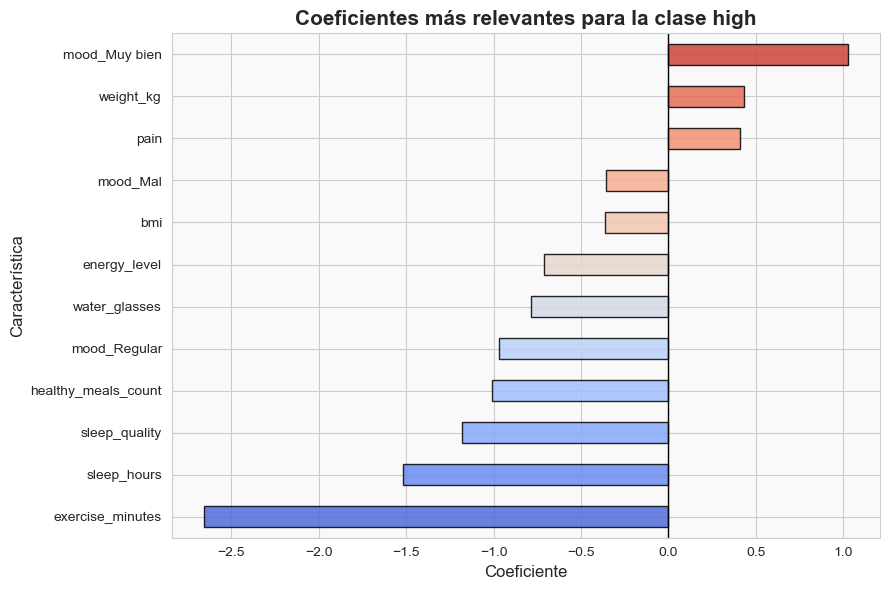

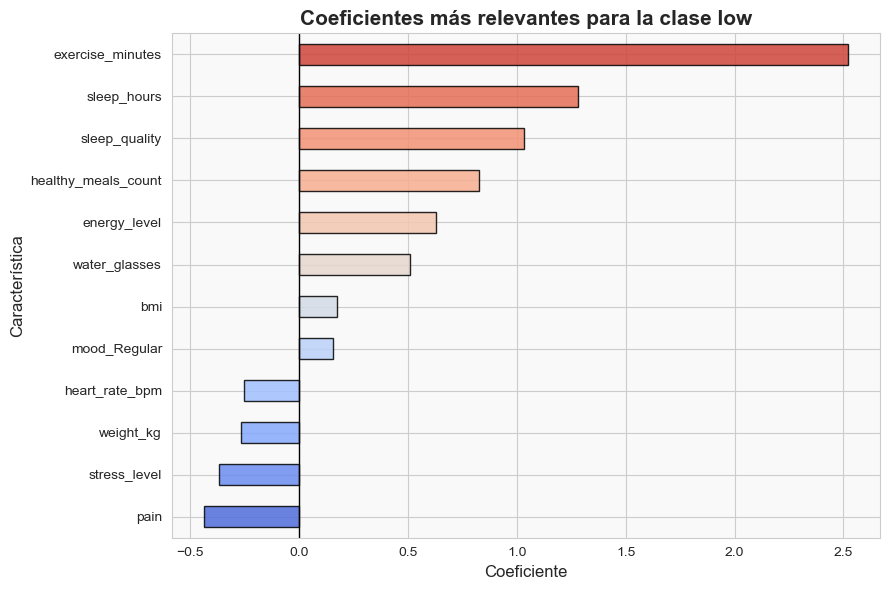

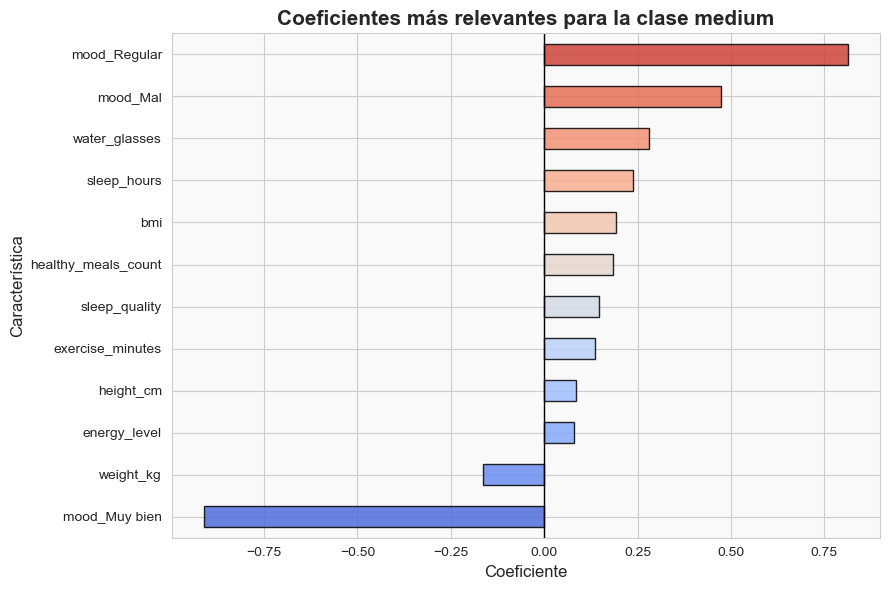

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

for class_name in logistic_coefficients.index:
    class_coefficients = (
        logistic_coefficients
        .loc[class_name]
        .sort_values(key=lambda values: values.abs(), ascending=False)
        .head(12)
        .sort_values()
    )
    
    plt.figure(figsize=(9,6))
    
    # Barras horizontales con colores diferenciados
    ax = class_coefficients.plot(
        kind="barh",
        color=sns.color_palette("coolwarm", len(class_coefficients)),
        edgecolor="black",
        alpha=0.85
    )
    
    # Títulos y etiquetas llamativas
    ax.set_title(f"Coeficientes más relevantes para la clase {class_name}", fontsize=15, fontweight="bold")
    ax.set_xlabel("Coeficiente", fontsize=12)
    ax.set_ylabel("Característica", fontsize=12)
    
    # Línea vertical en 0 para referencia
    plt.axvline(0, color="black", linewidth=1)
    
    # Fondo claro
    plt.gca().set_facecolor("#f9f9f9")
    
    plt.tight_layout()
    plt.show()


### Interpretación de coeficientes

Un coeficiente positivo indica que, manteniendo las demás variables constantes, la característica aumenta la tendencia del modelo hacia una clase.

Un coeficiente negativo indica que reduce esa tendencia.

Esto no demuestra causalidad.

Las relaciones también dependen de:

- Escalado.
- Correlación entre variables.
- Distribución de los datos sintéticos.
- Reglas utilizadas para crear `risk_level`.

## 12. Importancia de variables en Random Forest

Random Forest permite obtener una medida de importancia basada en la reducción de impureza.

Esta importancia muestra qué variables fueron más utilizadas para separar los registros durante el entrenamiento.

No debe interpretarse como causalidad.

In [48]:
random_forest_pipeline = joblib.load(
    RANDOM_FOREST_MODEL_PATH
)

forest_preprocessor = (
    random_forest_pipeline.named_steps[
        "preprocessor"
    ]
)

forest_classifier = (
    random_forest_pipeline.named_steps[
        "classifier"
    ]
)

forest_feature_names = (
    forest_preprocessor
    .get_feature_names_out()
)

forest_importances = pd.Series(
    forest_classifier.feature_importances_,
    index=forest_feature_names,
    name="importance",
).sort_values(
    ascending=False
)

forest_importances.head(15)

exercise_minutes      0.1519
energy_level          0.1411
stress_level          0.1187
sleep_hours           0.1046
pain                  0.0756
sleep_quality         0.0742
water_glasses         0.0686
healthy_meals_count   0.0296
heart_rate_bpm        0.0293
mood_Regular          0.0253
bmi                   0.0158
glucose_mg_dl         0.0157
meditation_minutes    0.0155
weight_kg             0.0155
systolic_mmhg         0.0150
Name: importance, dtype: float64

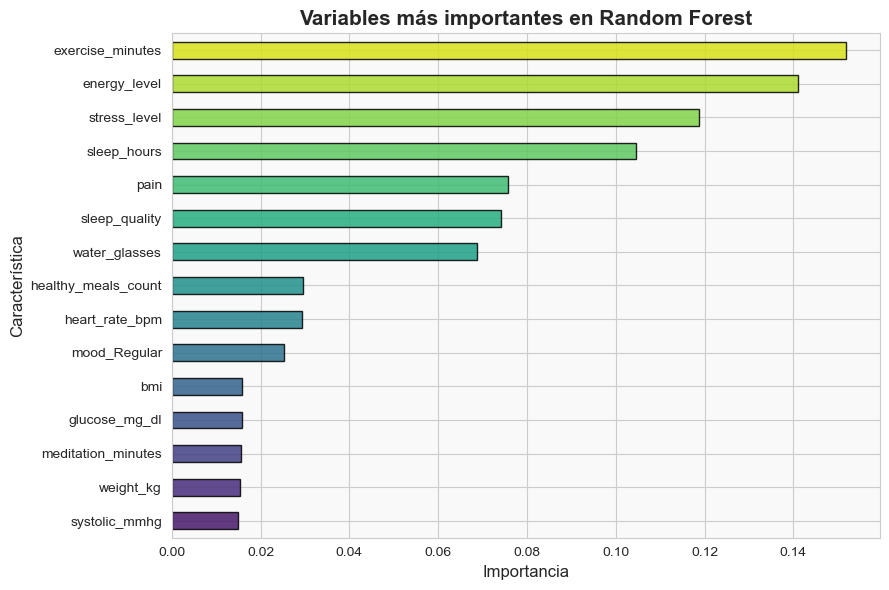

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

top_forest_importances = (
    forest_importances
    .head(15)
    .sort_values()
)

plt.figure(figsize=(9,6))

ax = top_forest_importances.plot(
    kind="barh",
    color=sns.color_palette("viridis", len(top_forest_importances)),
    edgecolor="black",
    alpha=0.85
)

# Títulos y etiquetas llamativas
ax.set_title("Variables más importantes en Random Forest", fontsize=15, fontweight="bold")
ax.set_xlabel("Importancia", fontsize=12)
ax.set_ylabel("Característica", fontsize=12)

# Fondo claro
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()


### Comparación de interpretabilidad

La Regresión Logística permite conocer la dirección de la relación de cada variable con cada clase.

Random Forest permite estimar qué variables participaron más en las decisiones, pero no muestra directamente si una variable incrementa o reduce el riesgo.

Para una aplicación de bienestar, la interpretabilidad es relevante porque Backend y Frontend deberán mostrar mensajes comprensibles sin presentar las predicciones como diagnósticos.

## 13. Selección provisional del modelo

La selección provisional se realizará considerando:

- F1 macro.
- Recall de la clase `high`.
- Accuracy.
- ROC-AUC.
- Equilibrio entre clases.
- Interpretabilidad.
- Complejidad.
- Tamaño y facilidad de integración.

In [51]:
selection_rows = []

for model_name, model_metrics in metrics_by_model.items():
    report = model_metrics[
        "classification_report"
    ]

    selection_rows.append(
        {
            "model": model_name,
            "accuracy": model_metrics[
                "accuracy"
            ],
            "f1_macro": model_metrics[
                "f1_macro"
            ],
            "roc_auc_weighted_ovr": (
                model_metrics[
                    "roc_auc_weighted_ovr"
                ]
            ),
            "high_precision": report[
                "high"
            ]["precision"],
            "high_recall": report[
                "high"
            ]["recall"],
            "high_f1": report[
                "high"
            ]["f1-score"],
        }
    )

selection_table = (
    pd.DataFrame(selection_rows)
    .sort_values(
        by=[
            "f1_macro",
            "high_recall",
            "accuracy",
        ],
        ascending=False,
    )
)

selection_table.round(4)

,model,accuracy,f1_macro,roc_auc_weighted_ovr,high_precision,high_recall,high_f1
0,logistic_regression,0.8933,0.8933,0.9771,0.8549,0.9066,0.8800
1,random_forest,0.8824,0.8825,0.9701,0.8446,0.8956,0.8693


In [52]:
provisional_best_model = (
    selection_table.iloc[0]["model"]
)

print("Mejor modelo provisional:")
print(provisional_best_model)

Mejor modelo provisional:
logistic_regression


### Decisión provisional

La Regresión Logística se selecciona provisionalmente como el mejor clasificador inicial porque:

- Presenta el mayor F1 macro.
- Obtiene mayor Accuracy.
- Logra mayor ROC-AUC.
- Mantiene un buen Recall para la clase `high`.
- Tiene un comportamiento equilibrado entre clases.
- Es más sencilla de interpretar.
- Su pipeline puede serializarse e integrarse con facilidad.

Random Forest continuará como modelo candidato durante el ajuste de hiperparámetros.

## 14. Preparación del ajuste de hiperparámetros

La selección actual todavía no es definitiva.

El siguiente paso será ajustar los hiperparámetros de ambos modelos utilizando exclusivamente:

- Conjunto de entrenamiento.
- Conjunto de validación.

El conjunto de prueba continuará reservado.

Los parámetros por revisar serán:

### Regresión Logística

- `C`
- `class_weight`
- `solver`

### Random Forest

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`
- `class_weight`

## 15. Política de selección definitiva

El mejor modelo ajustado será seleccionado utilizando principalmente:

1. F1 macro.
2. Recall de la clase `high`.
3. ROC-AUC multiclase.
4. Estabilidad entre entrenamiento y validación.
5. Interpretabilidad.
6. Complejidad y tamaño del artefacto.

Después de seleccionar el modelo, se realizará una sola evaluación sobre el conjunto de prueba.

## 16. Conclusión parcial

La comparación inicial indica que ambos modelos ofrecen un desempeño alto sobre el conjunto de validación sintético.

La Regresión Logística presenta una ventaja ligera y consistente, por lo que se mantiene como mejor modelo provisional.

Antes de utilizar el conjunto de prueba deberán realizarse:

- Ajuste de hiperparámetros.
- Comparación del modelo ajustado.
- Revisión de sobreajuste.
- Selección definitiva.
- Guardado del mejor pipeline.

## 17. Comparación entre el flujo inicial y el flujo temporal seguro

El primer entrenamiento se realizó utilizando datos procesados antes de la división temporal.

Posteriormente se corrigió el procedimiento mediante:

1. División temporal del dataset crudo.
2. Cálculo de medianas y modas únicamente con entrenamiento.
3. Aplicación de esos valores a validación y prueba.
4. Reentrenamiento y nuevo ajuste de hiperparámetros.

Esta sección compara ambos resultados para medir el efecto de la corrección metodológica.

In [53]:
SAFE_COMPARISON_PATH = (
    REPORTS_DIR
    / "safe_model_comparison.csv"
)

SAFE_BEST_METRICS_PATH = (
    REPORTS_DIR
    / "safe_best_validation_metrics.json"
)

SAFE_TUNING_RESULTS_PATH = (
    REPORTS_DIR
    / "safe_hyperparameter_tuning_results.csv"
)

safe_paths = {
    "Comparación segura": SAFE_COMPARISON_PATH,
    "Mejores métricas seguras": SAFE_BEST_METRICS_PATH,
    "Resultados de ajuste seguro": SAFE_TUNING_RESULTS_PATH,
}

for name, path in safe_paths.items():
    print(f"{name}: {path.exists()} — {path}")

Comparación segura: True — C:\Users\otero\OneDrive\Desktop\9A-IDGS-ECBD-VitalMind-\ml-service\app\..\reports\classification\safe_model_comparison.csv
Mejores métricas seguras: True — C:\Users\otero\OneDrive\Desktop\9A-IDGS-ECBD-VitalMind-\ml-service\app\..\reports\classification\safe_best_validation_metrics.json
Resultados de ajuste seguro: True — C:\Users\otero\OneDrive\Desktop\9A-IDGS-ECBD-VitalMind-\ml-service\app\..\reports\classification\safe_hyperparameter_tuning_results.csv


In [54]:
safe_comparison_df = pd.read_csv(
    SAFE_COMPARISON_PATH
)

safe_tuning_df = pd.read_csv(
    SAFE_TUNING_RESULTS_PATH
)

with SAFE_BEST_METRICS_PATH.open(
    "r",
    encoding="utf-8",
) as safe_metrics_file:
    safe_best_metrics = json.load(
        safe_metrics_file
    )

print("Resultados seguros cargados correctamente.")
print(
    f"Configuraciones evaluadas: "
    f"{len(safe_tuning_df):,}"
)

Resultados seguros cargados correctamente.
Configuraciones evaluadas: 338


In [55]:
safe_comparison_df


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,roc_auc_weighted_ovr
0,logistic_regression,0.8865,0.8866,0.8865,0.8859,0.8865,0.9767
1,random_forest,0.8782,0.8785,0.8782,0.8778,0.8781,0.9709


### Modelos iniciales con el flujo seguro

Esta tabla muestra el desempeño de Regresión Logística y Random Forest después de corregir el preprocesamiento temporal.

La comparación sigue utilizando exclusivamente el conjunto de validación.

In [56]:
safe_initial_display = (
    safe_comparison_df[
        [
            "model",
            "accuracy",
            "precision_weighted",
            "recall_weighted",
            "f1_weighted",
            "f1_macro",
            "roc_auc_weighted_ovr",
        ]
    ]
    .copy()
    .sort_values(
        by="f1_macro",
        ascending=False,
    )
)

safe_initial_display

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,roc_auc_weighted_ovr
0,logistic_regression,0.8865,0.8866,0.8865,0.8859,0.8865,0.9767
1,random_forest,0.8782,0.8785,0.8782,0.8778,0.8781,0.9709


In [57]:
initial_best_metrics = {
    "flow": "initial_global_imputation",
    "model": "logistic_regression",
    "C": 1.0,
    "class_weight": "balanced",
    "solver": "lbfgs",
    "accuracy": 0.8933,
    "f1_macro": 0.8933,
    "high_recall": 0.9066,
    "roc_auc_weighted_ovr": 0.9771,
}

safe_best_summary = {
    "flow": "safe_temporal_imputation",
    "model": safe_best_metrics["model"],
    "C": safe_best_metrics[
        "parameters"
    ].get("C"),
    "class_weight": safe_best_metrics[
        "parameters"
    ].get("class_weight"),
    "solver": safe_best_metrics[
        "parameters"
    ].get("solver"),
    "accuracy": safe_best_metrics[
        "accuracy"
    ],
    "f1_macro": safe_best_metrics[
        "f1_macro"
    ],
    "high_recall": safe_best_metrics[
        "high_recall"
    ],
    "roc_auc_weighted_ovr": safe_best_metrics[
        "roc_auc_weighted_ovr"
    ],
}

flow_comparison_df = pd.DataFrame(
    [
        initial_best_metrics,
        safe_best_summary,
    ]
)

flow_comparison_df.round(4)

,flow,model,C,class_weight,solver,accuracy,f1_macro,high_recall,roc_auc_weighted_ovr
0,initial_global_imputation,logistic_regression,1.0000,balanced,lbfgs,0.8933,0.8933,0.9066,0.9771
1,safe_temporal_imputation,logistic_regression,10.0000,balanced,lbfgs,0.8892,0.8890,0.9011,0.9765


<Figure size 1000x600 with 0 Axes>

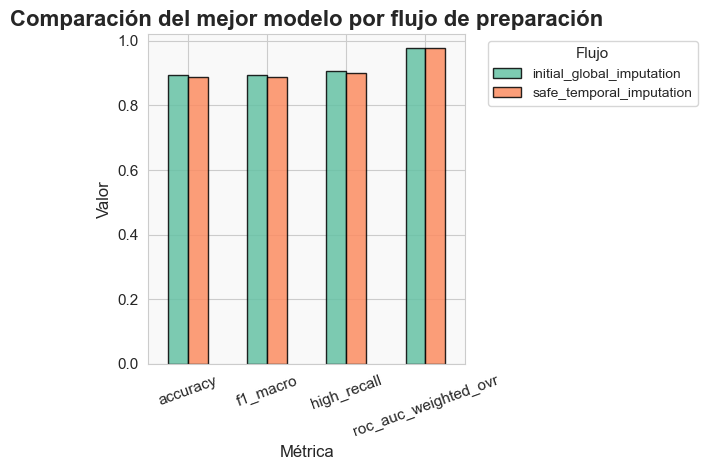

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

flow_metrics_plot = (
    flow_comparison_df
    .set_index("flow")[metric_columns]
    .T
)

plt.figure(figsize=(10,6))

ax = flow_metrics_plot.plot(
    kind="bar",
    color=sns.color_palette("Set2", len(flow_metrics_plot.columns)),
    edgecolor="black",
    alpha=0.85
)

# Títulos y etiquetas llamativas
ax.set_title("Comparación del mejor modelo por flujo de preparación", fontsize=16, fontweight="bold")
ax.set_xlabel("Métrica", fontsize=12)
ax.set_ylabel("Valor", fontsize=12)
ax.set_ylim(0, 1.02)

# Ajuste de ticks
ax.tick_params(axis="x", rotation=20, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# Leyenda estilizada
ax.legend(title="Flujo", fontsize=10, title_fontsize=11, bbox_to_anchor=(1.05, 1), loc="upper left")

# Fondo claro
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()


In [60]:
metric_differences = pd.DataFrame(
    {
        "metric": metric_columns,
        "initial_value": [
            initial_best_metrics[column]
            for column in metric_columns
        ],
        "safe_value": [
            safe_best_summary[column]
            for column in metric_columns
        ],
    }
)

metric_differences[
    "absolute_difference"
] = (
    metric_differences["safe_value"]
    - metric_differences["initial_value"]
)

metric_differences[
    "relative_difference_percent"
] = (
    metric_differences[
        "absolute_difference"
    ]
    / metric_differences[
        "initial_value"
    ]
    * 100
)

metric_differences.round(4)

,metric,initial_value,safe_value,absolute_difference,relative_difference_percent
0,accuracy,0.8933,0.8892,-0.0041,-0.4598
1,f1_macro,0.8933,0.8890,-0.0043,-0.4844
2,high_recall,0.9066,0.9011,-0.0055,-0.6068
3,roc_auc_weighted_ovr,0.9771,0.9765,-0.0006,-0.0566


### Interpretación de las diferencias

El flujo temporal seguro presenta una reducción pequeña en las métricas de validación.

Esta reducción no representa un problema del modelo.

Al contrario, indica que el resultado inicial podía estar ligeramente favorecido por el uso de estadísticas calculadas con información de todo el periodo.

Las métricas seguras son preferibles porque representan de manera más realista el comportamiento esperado cuando el modelo recibe datos futuros.


## Comparación de parámetros


In [61]:
parameter_comparison = flow_comparison_df[
    [
        "flow",
        "model",
        "C",
        "class_weight",
        "solver",
    ]
].copy()

parameter_comparison

,flow,model,C,class_weight,solver
0,initial_global_imputation,logistic_regression,1.0000,balanced,lbfgs
1,safe_temporal_imputation,logistic_regression,10.0000,balanced,lbfgs


### Cambio en los hiperparámetros

El mejor modelo continúa siendo Regresión Logística balanceada con el solver `lbfgs`.

El valor de regularización cambió:

- Flujo inicial: `C = 1.0`
- Flujo temporal seguro: `C = 10.0`

Un valor mayor de `C` implica una regularización más débil.

Esto indica que, con los datos preparados de forma temporalmente segura, el modelo encontró un mejor equilibrio permitiendo coeficientes ligeramente menos restringidos. 

## Resultados del ajuste seguro

In [62]:
safe_tuning_columns = [
    "model",
    "accuracy",
    "f1_macro",
    "high_recall",
    "high_f1",
    "roc_auc_weighted_ovr",
]

safe_tuning_df[
    safe_tuning_columns
].head(15).round(4)

,model,accuracy,f1_macro,high_recall,high_f1,roc_auc_weighted_ovr
0,logistic_regression,0.8892,0.8890,0.9011,0.8747,0.9765
1,logistic_regression,0.8892,0.8884,0.8462,0.8676,0.9771
2,logistic_regression,0.8892,0.8884,0.8462,0.8676,0.9770
3,logistic_regression,0.8878,0.8883,0.9066,0.8800,0.9766
4,random_forest,0.8878,0.8881,0.9231,0.8773,0.9697
5,random_forest,0.8878,0.8881,0.9231,0.8773,0.9697
6,logistic_regression,0.8878,0.8880,0.9011,0.8770,0.9767
7,logistic_regression,0.8878,0.8878,0.9066,0.8753,0.9766
8,logistic_regression,0.8865,0.8865,0.9011,0.8747,0.9767
9,random_forest,0.8851,0.8855,0.9176,0.8766,0.9701


In [63]:
best_safe_by_model = (
    safe_tuning_df
    .sort_values(
        by=[
            "f1_macro",
            "high_recall",
            "roc_auc_weighted_ovr",
            "accuracy",
        ],
        ascending=False,
    )
    .groupby(
        "model",
        as_index=False,
    )
    .first()
)

best_safe_by_model[
    safe_tuning_columns
].round(4)

,model,accuracy,f1_macro,high_recall,high_f1,roc_auc_weighted_ovr
0,logistic_regression,0.8892,0.8890,0.9011,0.8747,0.9765
1,random_forest,0.8878,0.8881,0.9231,0.8773,0.9697


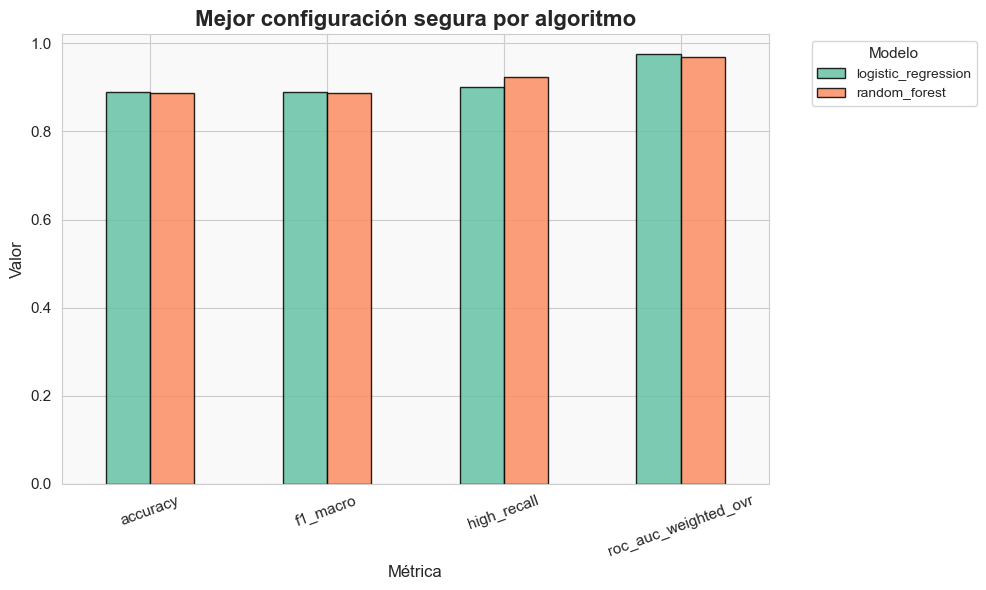

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

ax = (
    best_safe_by_model
    .set_index("model")[["accuracy","f1_macro","high_recall","roc_auc_weighted_ovr"]]
    .T
    .plot(
        kind="bar",
        figsize=(10,6),
        color=sns.color_palette("Set2", len(best_safe_by_model["model"].unique())),
        edgecolor="black",
        alpha=0.85
    )
)

# Títulos y etiquetas llamativas
ax.set_title("Mejor configuración segura por algoritmo", fontsize=16, fontweight="bold")
ax.set_xlabel("Métrica", fontsize=12)
ax.set_ylabel("Valor", fontsize=12)
ax.set_ylim(0, 1.02)

# Ajuste de ticks
ax.tick_params(axis="x", rotation=20, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# Leyenda estilizada
ax.legend(title="Modelo", fontsize=10, title_fontsize=11, bbox_to_anchor=(1.05, 1), loc="upper left")

# Fondo claro
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()


## 18. Decisión sobre el flujo definitivo

El flujo temporal seguro será utilizado para todas las etapas posteriores.

Se descartan como referencia definitiva los artefactos generados con imputación global.

El modelo seleccionado para la evaluación final será:

- Algoritmo: Regresión Logística.
- `C`: 10.0.
- `class_weight`: `balanced`.
- `solver`: `lbfgs`.
- F1 macro de validación: aproximadamente 0.8890.
- Recall de la clase `high`: aproximadamente 0.9011.
- ROC-AUC multiclase: aproximadamente 0.9765.

El conjunto de prueba permanece sin utilizar.

## 19. Justificación de la decisión

El flujo temporal seguro se selecciona porque:

- Evita calcular estadísticas con información futura.
- Mantiene una separación cronológica realista.
- Produce métricas de validación altas y equilibradas.
- Conserva un Recall superior al 90 % para la clase `high`.
- Permite reproducir el proceso de preparación.
- Es más adecuado para una futura operación con datos reales.
- Reduce el riesgo de presentar resultados excesivamente optimistas.

## 20. Preparación para la evaluación final

El siguiente paso será realizar una única evaluación sobre el conjunto de prueba.

Durante esa evaluación:

1. Se cargará el pipeline seguro ya seleccionado.
2. No se modificarán los hiperparámetros.
3. No se volverá a seleccionar el modelo.
4. Se calcularán las métricas finales.
5. Se guardarán las predicciones de prueba.
6. Se generará una matriz de confusión final.
7. Se conservará el resultado como estimación final del clasificador.

El conjunto de prueba no deberá utilizarse para realizar nuevos ajustes.